### Self Practice

In [25]:
import asyncio
from typing import TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, END, START
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command, interrupt
import time

In [2]:
class ConditionalState(TypedDict):
    message: str
    category: str
    result: str

In [3]:
def classify_category(state: ConditionalState) -> dict:
    if "payment" in state["message"].lower() or "invoice" in state["message"].lower():
        category = "billing"
    elif "technical" in state["message"].lower() or "error" in state["message"].lower():
        category = "technical"
    else:
        category = "general"
    return {"category": category}


def billing_handler(state: ConditionalState) -> dict:
    return {"result": "Billing related message: " + state["message"]}


def technical_handler(state: ConditionalState) -> dict:
    return {"result": "Technical related message: " + state["message"]}


def general_handler(state: ConditionalState) -> dict:
    return {"result": "General message: " + state["message"]}


def route_ricket(state: ConditionalState) -> str:
    return f"{state['category']}"

In [76]:
graph = StateGraph(ConditionalState)

graph.add_node("classify_category", classify_category)
graph.add_node("billing_handler", billing_handler)
graph.add_node("technical_handler", technical_handler)
graph.add_node("general_handler", general_handler)

graph.set_entry_point("classify_category")

graph.add_conditional_edges(
    "classify_category",
    route_ricket,
    {"billing": "billing_handler", "technical": "technical_handler", "general": "general_handler"},
)

graph.add_edge("billing_handler", END)
graph.add_edge("technical_handler", END)
graph.add_edge("general_handler", END)

app = graph.compile()

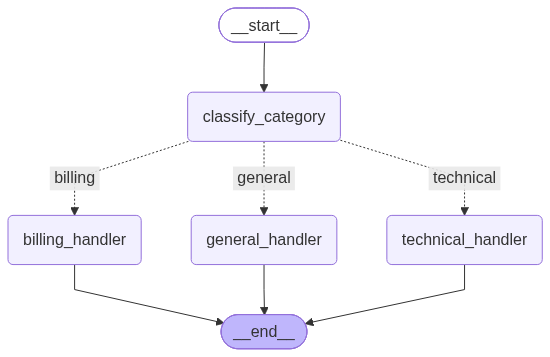

In [77]:
app

In [84]:
app.invoke(
    {
        "message": "My payment failed",
    }
)

{'message': 'My payment failed',
 'category': 'billing',
 'result': 'Billing related message: My payment failed'}

In [ ]:
class RAGState(TypedDict):
    query: str
    retrived_docs: Annotated[list[str], operator.add]
    retrive_attempt: int
    response: str

In [145]:
def retrive_docs(state: RAGState) -> dict:
    return {
        "retrived_docs": [
            f"retrived docuemnts here for {state['query']} in attempt {state['retrive_attempt']}"
        ],
        "retrive_attempt": state["retrive_attempt"] + 1,
    }


def genrate_response(state: RAGState) -> dict:
    # actual genrator call here
    return {"response": f"Genrate response using {state['retrived_docs']}"}


def evalute_retrive_docs(state: RAGState) -> dict:
    if state["retrive_attempt"] < 3:
        # actual logic here to evalute docs
        for doc in state["retrived_docs"]:
            if "attempt 1" in doc:
                return "genrate"
        return "retry_retrive"

    return "genrate"

In [146]:
graph = StateGraph(RAGState)

graph.add_node("retrive_docs", retrive_docs)
graph.add_node("genrate_response", genrate_response)

graph.set_entry_point("retrive_docs")
graph.add_conditional_edges(
    "retrive_docs",
    evalute_retrive_docs,
    {"genrate": "genrate_response", "retry_retrive": "retrive_docs"},
)
graph.add_edge("genrate_response", END)

app = graph.compile()

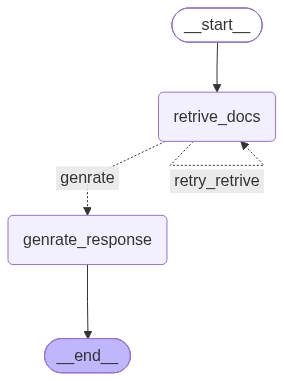

In [147]:
app

In [148]:
result = await app.ainvoke(
    {"query": "test query", "retrived_docs": [], "retrive_attempt": 0, "response": ""}
)

In [149]:
result

{'query': 'test query',
 'retrived_docs': ['retrived docuemnts here for test query in attempt 0',
  'retrived docuemnts here for test query in attempt 1'],
 'retrive_attempt': 2,
 'response': "Genrate response using ['retrived docuemnts here for test query in attempt 0', 'retrived docuemnts here for test query in attempt 1']"}

In [7]:
class TestPersistenceState(TypedDict):
    process_1: bool
    process_2: bool
    process_3: bool

In [16]:
def process_1(state: TestPersistenceState) -> dict:
    time.sleep(5)
    print("process 1 completed")
    return {"process_1": True}


def process_2(state: TestPersistenceState) -> dict:
    time.sleep(5)
    print("process 2 completed")
    return {"process_2": True}


def process_3(state: TestPersistenceState) -> dict:
    time.sleep(5)
    print("process 3 completed")
    return {"process_3": True}

In [17]:
checkpointer = InMemorySaver()

graph = StateGraph(TestPersistenceState)

graph.add_node("process_1", process_1)
graph.add_node("process_2", process_2)
graph.add_node("process_3", process_3)

graph.add_edge(START, "process_1")
graph.add_edge("process_1", "process_2")
graph.add_edge("process_2", "process_3")
graph.add_edge("process_3", END)


app = graph.compile(checkpointer=checkpointer)

In [30]:
config = {"configurable": {"thread_id": "test-1"}}

result = app.invoke({"process_1": False, "process_2": False, "process_3": False}, config=config)

print(result)

process 1 completed
process 2 completed
process 3 completed
{'process_1': True, 'process_2': True, 'process_3': True}


### Human in loop

In [ ]:
class Ticket(TypedDict, total=False):
    ticket_id: str
    customer: str
    amount: float
    reason: str
    approval: str
    result: str

In [4]:
def prepare_refund(state: Ticket) -> dict:
    print("Prepare refund")

    return {"customer": "Test 1", "amount": 258.5, "reason": "for testing purpose"}


def human_approval(state: Ticket) -> dict:
    print("Human approval")

    decision = interrupt(
        {
            "type": "refund_approval",
            "ticked_id": state["ticket_id"],
            "customer": state["customer"],
            "amount": state["amount"],
            "reason": state["reason"],
            "message": "Approve this refund ?",
        }
    )

    return {
        "approval": decision,
    }


def route_result(state: Ticket) -> str:
    if state["approval"] == "approved":
        return "execute_refund"

    return "reject_refund"


def execute_refund(state: Ticket) -> dict:
    print("Execute refund")
    return {"result": f"Refund {state['amount']} to {state['customer']}"}


def reject_refund(state: Ticket) -> dict:
    print("Reject refund")

    return {"result": f"Refund rejected by human reviewer of {state['customer']}"}

In [5]:
graph = StateGraph(Ticket)

graph.add_node("prepare_refund", prepare_refund)
graph.add_node("human_approval", human_approval)
graph.add_node("execute_refund", execute_refund)
graph.add_node("reject_refund", reject_refund)

graph.add_edge(START, "prepare_refund")
graph.add_edge("prepare_refund", "human_approval")
graph.add_conditional_edges("human_approval", route_result, ["execute_refund", "reject_refund"])
graph.add_edge("execute_refund", END)
graph.add_edge("reject_refund", END)

checkpointer = InMemorySaver()
app = graph.compile(checkpointer=checkpointer)

In [24]:
config = {"configurable": {"thread_id": "refund-5001"}}

first = app.invoke({"ticket_id": "test-001"}, config=config, version="v2")

print("\nFIRST RESULT:")
print(first)

if first.interrupts:
    print("\nHUMAN REVIEW REQUEST:")
    print(first.interrupts[0].value)

Prepare refund
Human approval

FIRST RESULT:
GraphOutput(value={'ticket_id': 'test-001', 'customer': 'Test 1', 'amount': 258.5, 'reason': 'for testing purpose', 'approval': 'rejected', 'result': 'Refund rejected by human reviewer of Test 1'}, interrupts=(Interrupt(value={'type': 'refund_approval', 'ticked_id': 'test-001', 'customer': 'Test 1', 'amount': 258.5, 'reason': 'for testing purpose', 'message': 'Approve this refund ?'}, id='1b0de126bfb9611b9cb49a094301745f'),))

HUMAN REVIEW REQUEST:
{'type': 'refund_approval', 'ticked_id': 'test-001', 'customer': 'Test 1', 'amount': 258.5, 'reason': 'for testing purpose', 'message': 'Approve this refund ?'}


In [21]:
resume = app.invoke(Command(resume="rejected"), config=config, version="v2")

print(resume.value)

Human approval
Reject refund
{'ticket_id': 'test-001', 'customer': 'Test 1', 'amount': 258.5, 'reason': 'for testing purpose', 'approval': 'rejected', 'result': 'Refund rejected by human reviewer of Test 1'}


In [26]:
class TicketState(TypedDict, total=False):
    ticket_id: str
    customer: str
    analysis: str
    draft: str
    sent: bool

In [27]:
async def load_ticket(state: TicketState) -> dict:
    print("[node] load_ticket")
    await asyncio.sleep(1)

    return {"customer": "Acme Corp"}


async def analyze_ticker(state: TicketState) -> dict:
    print("[node] analyze_ticket")
    await asyncio.sleep(1)

    return {"analysis": "Duplicate billing is likely. Verify invoice/payment IDs."}


async def draft_response(state: TicketState) -> dict:
    print("[node] draft_response")
    await asyncio.sleep(1)

    return {
        "draft": (
            "Hi Acme Corp, we identified a possible duplicate charge. "
            "We are reviewing the payment records now."
        )
    }


async def send_response(state: TicketState) -> dict:
    print("[node] send_response")
    await asyncio.sleep(1)

    return {"sent": True}

In [28]:
graph = StateGraph(TicketState)

graph.add_node("load_ticket", load_ticket)
graph.add_node("analyze_ticker", analyze_ticker)
graph.add_node("draft_response", draft_response)
graph.add_node("send_response", send_response)

graph.set_entry_point("load_ticket")
graph.add_edge("load_ticket", "analyze_ticker")
graph.add_edge("analyze_ticker", "draft_response")
graph.add_edge("draft_response", "send_response")
graph.add_edge("send_response", END)

app = graph.compile()

In [39]:
async def main() -> None:
    initial_state = {"ticket_id": "test-1002"}

    async for chunk in app.astream(initial_state, stream_mode="updates", version="v2"):
        print("chunk:\n")
        print(chunk, "=" * 50)
        if chunk["type"] != "updates":
            continue

        print("\nSTREAM EVENT:")
        print(chunk["data"])


await main()

[node] load_ticket
chunk:

{'type': 'updates', 'ns': (), 'data': {'load_ticket': {'customer': 'Acme Corp'}}} ==================================================

STREAM EVENT:
{'load_ticket': {'customer': 'Acme Corp'}}
[node] analyze_ticket
chunk:

{'type': 'updates', 'ns': (), 'data': {'analyze_ticker': {'analysis': 'Duplicate billing is likely. Verify invoice/payment IDs.'}}} ==================================================

STREAM EVENT:
{'analyze_ticker': {'analysis': 'Duplicate billing is likely. Verify invoice/payment IDs.'}}
[node] draft_response
chunk:

{'type': 'updates', 'ns': (), 'data': {'draft_response': {'draft': 'Hi Acme Corp, we identified a possible duplicate charge. We are reviewing the payment records now.'}}} ==================================================

STREAM EVENT:
{'draft_response': {'draft': 'Hi Acme Corp, we identified a possible duplicate charge. We are reviewing the payment records now.'}}
[node] send_response
chunk:

{'type': 'updates', 'ns': (), 'da

In [40]:
class SupportState(TypedDict, total=False):
    ticket_id: str
    customer: str
    issue: str
    analysis: str
    draft: str
    risk: str
    approval: str
    status: str

In [ ]:
async def load_ticket(state: SupportState) -> dict:
    print("[load_ticket]")
    await asyncio.sleep(0.5)

    return {
        "customer": "Acme Corp",
        "issue": "Customer may have been charged twice for one invoice.",
        "status": "ticket_loaded",
    }


async def analyze_issue(state: SupportState) -> dict:
    print("[analyze_issue]")
    await asyncio.sleep(0.8)

    return {
        "analysis": (
            "There is evidence of a possible duplicate payment. "
            "A refund may be appropriate, but a human should review before execution."
        ),
        "risk": "high",
        "status": "analyzed",
    }


async def draft_response(state: SupportState) -> dict:
    print("[draft_response]")
    await asyncio.sleep(0.8)

    return {
        "draft": (
            f"Hi {state['customer']},\n\n"
            "We found a possible duplicate charge for your invoice. "
            "Our billing team is reviewing it now and will confirm the next step."
        ),
        "status": "draft_ready",
    }


async def human_approval(state: SupportState) -> dict:
    print("[human_approval] PAUSED")

    decision = interrupt(
        {
            "type": "support_response_approval",
            "ticket_id": state["ticket_id"],
            "customer": state["customer"],
            "risk": state["risk"],
            "analysis": state["analysis"],
            "draft": state["draft"],
            "question": "Approve this response for sending?",
        }
    )

    return {
        "approval": decision,
        "status": "human_review_complete",
    }


def route_after_approval(state: SupportState) -> str:
    if state.get("approval") == "approved":
        return "execute_response"

    return "reject_response"


def execute_response(state: SupportState) -> dict:
    print("[execute_response]")

    return {"status": "response_sent"}


def reject_response(state: SupportState) -> dict:
    print("[reject_response]")

    return {"status": "response_rejected"}

In [47]:
graph = StateGraph(SupportState)

graph.add_node("load_ticket", load_ticket)
graph.add_node("analyze_issue", analyze_issue)
graph.add_node("draft_response", draft_response)
graph.add_node("human_approval", human_approval)
graph.add_node("execute_response", execute_response)
graph.add_node("reject_response", reject_response)


graph.add_edge(START, "load_ticket")
graph.add_edge("load_ticket", "analyze_issue")
graph.add_edge("analyze_issue", "draft_response")
graph.add_edge("draft_response", "human_approval")
graph.add_conditional_edges(
    "human_approval", route_after_approval, ["execute_response", "reject_response"]
)
graph.add_edge("execute_response", END)
graph.add_edge("reject_response", END)

checkpointer = InMemorySaver()
app = graph.compile(checkpointer=checkpointer)

In [84]:
async def first_run(thread_id: str) -> None:
    config = {"configurable": {"thread_id": thread_id}}

    print("\n=== FIRST RUN ===")

    async for chunk in app.astream(
        {"ticket_id": "T-9001"},
        config=config,
        stream_mode="updates",
        version="v2",
    ):
        if chunk["type"] != "updates":
            continue

        print("STREAM:", chunk["data"])

    snapshot = app.get_state(config)
    print("\nPERSISTED STATE:")
    print(snapshot.values)


async def resume_after_human(thread_id: str, decision: str) -> None:
    config = {"configurable": {"thread_id": thread_id}}

    print("\n=== RESUME ===")

    async for chunk in app.astream(
        Command(resume=decision),
        config=config,
        stream_mode="updates",
        version="v2",
    ):
        if chunk["type"] != "updates":
            continue

        print("STREAM:", chunk["data"])


async def demo() -> None:
    thread_id = "support-ticket-T-9001"

    # Request approval phase.
    await first_run(thread_id)

    human_decision = "approved"

    await resume_after_human(thread_id, human_decision)

In [85]:
await demo()


=== FIRST RUN ===
[load_ticket]
STREAM: {'load_ticket': {'customer': 'Acme Corp', 'issue': 'Customer may have been charged twice for one invoice.', 'status': 'ticket_loaded'}}
[analyze_issue]
STREAM: {'analyze_issue': {'analysis': 'There is evidence of a possible duplicate payment. A refund may be appropriate, but a human should review before execution.', 'risk': 'high', 'status': 'analyzed'}}
[draft_response]
STREAM: {'draft_response': {'draft': 'Hi Acme Corp,\n\nWe found a possible duplicate charge for your invoice. Our billing team is reviewing it now and will confirm the next step.', 'status': 'draft_ready'}}
[human_approval] PAUSED
STREAM: {'__interrupt__': (Interrupt(value={'type': 'support_response_approval', 'ticket_id': 'T-9001', 'customer': 'Acme Corp', 'risk': 'high', 'analysis': 'There is evidence of a possible duplicate payment. A refund may be appropriate, but a human should review before execution.', 'draft': 'Hi Acme Corp,\n\nWe found a possible duplicate charge for yo